# Initial Condition (IC) Fuzzing   Beta(α,α) IS Proposal

Analysis notebook for `ic_fuzzing_local.py` results.

**Proposal**: joint IS over all 3 IC variables per traffic vehicle:
- **lane**: Bernoulli(`lane_bias_q`), nominal q=0.5
- **pos_offset**: Beta(`beta_alpha`, `beta_alpha`) scaled to [-5, 5]   α<1 biases to extremes
- **spd_offset**: Beta(`beta_alpha`, `beta_alpha`) scaled to [-1, 1]

\beta=1 is uniform (nominal). \beta<1 is U-shaped, samples extremes 



Direct Sampling comparison uses the **100k nominal run**

In [69]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Paths (notebook lives in colabs/, kernel cwd = colabs/) ───────────────
IC_RESULTS_PATH = "results/ic_fuzzing_results.json"
# IC_NOMINAL_PATH = "results/initial_condition_100k_nominal.json"  # 100k nominal run
IC_NOMINAL_PATH = "results/initial_condition_1m_nominal.json"  # 1m nominal run

MODEL_PATH = "../merge/merge_ppo/PPO_1/final_model"

for p in [IC_RESULTS_PATH, IC_NOMINAL_PATH]:
    print(f"  {'OK' if os.path.exists(p) else 'MISSING':6s}  {p}")

  OK      results/ic_fuzzing_results.json
  OK      results/initial_condition_1m_nominal.json


## (a) Ground Truth   Direct Sampling (100k nominal IC)

In [70]:
NOMINAL_KEY = "q=0.50_a=1.00"  # nominal config: lane_bias_q=0.5, beta_alpha=1.0

with open(IC_NOMINAL_PATH) as f:
    nominal_data = json.load(f)

DS_WEIGHTS_100K     = np.array(nominal_data[NOMINAL_KEY]["is_weights"], dtype=float)
GROUND_TRUTH_P_FAIL = float(np.mean(DS_WEIGHTS_100K))
TOTAL_DS_EPISODES   = len(DS_WEIGHTS_100K)
TOTAL_DS_FAILURES   = int(np.sum(DS_WEIGHTS_100K > 0))

print(f"Ground-truth p_fail  = {GROUND_TRUTH_P_FAIL:.5f}")
print(f"Total DS episodes    = {TOTAL_DS_EPISODES:,}")
print(f"Total DS failures    = {TOTAL_DS_FAILURES:,}")
print(f"DS_WEIGHTS_100K      shape={DS_WEIGHTS_100K.shape}  mean={DS_WEIGHTS_100K.mean():.5f}")

Ground-truth p_fail  = 0.02076
Total DS episodes    = 1,000,000
Total DS failures    = 20,762
DS_WEIGHTS_100K      shape=(1000000,)  mean=0.02076


## Load IC Fuzzing Results (JSON)

In [71]:
with open(IC_RESULTS_PATH) as f:
    raw = json.load(f)

# Keys are compound strings like "q=0.50_a=1.00"
loaded = dict(raw)
keys   = sorted(loaded.keys())

print(f"Loaded {len(keys)} configs:")
for k in keys:
    r = loaded[k]
    print(f"  {k}  failures={r['num_failures']:4d}/{r['num_rollouts']:,}  "
          f"p_fail_is={r['p_fail_is']:.5f}  mlf_logp={r['mlf_logp']}")

Loaded 20 configs:
  q=0.10_a=0.30  failures=2289/20,000  p_fail_is=0.01839  mlf_logp=-2.0794415416798357
  q=0.10_a=0.50  failures=1882/20,000  p_fail_is=0.01962  mlf_logp=-2.0794415416798357
  q=0.10_a=0.90  failures=1395/20,000  p_fail_is=0.01980  mlf_logp=-2.0794415416798357
  q=0.10_a=1.00  failures=1328/20,000  p_fail_is=0.02092  mlf_logp=-2.0794415416798357
  q=0.30_a=0.30  failures=1426/20,000  p_fail_is=0.02481  mlf_logp=-2.0794415416798357
  q=0.30_a=0.50  failures=1148/20,000  p_fail_is=0.02011  mlf_logp=-2.0794415416798357
  q=0.30_a=0.90  failures= 847/20,000  p_fail_is=0.02050  mlf_logp=-2.0794415416798357
  q=0.30_a=1.00  failures= 795/20,000  p_fail_is=0.02131  mlf_logp=-2.0794415416798357
  q=0.50_a=0.30  failures= 763/20,000  p_fail_is=0.02962  mlf_logp=-2.0794415416798357
  q=0.50_a=0.50  failures= 601/20,000  p_fail_is=0.02026  mlf_logp=-2.0794415416798357
  q=0.50_a=0.90  failures= 457/20,000  p_fail_is=0.02179  mlf_logp=-2.0794415416798357
  q=0.50_a=1.00  failure

In [72]:
# Identify optimal proposal = closest p_fail_is to GROUND_TRUTH_P_FAIL.

OPT_KEY = min(
    loaded.keys(),
    key=lambda k: abs(loaded[k]["p_fail_is"] - GROUND_TRUTH_P_FAIL)
)
OPT_Q     = loaded[OPT_KEY]["lane_bias_q"]
OPT_ALPHA = loaded[OPT_KEY]["beta_alpha"]

print(f"Optimal proposal (closest IS p_fail to GT={GROUND_TRUTH_P_FAIL:.5f}): {OPT_KEY}")
print(f"  lane_bias_q  = {OPT_Q}   (nominal=0.5)")
print(f"  beta_alpha   = {OPT_ALPHA}  (nominal=1.0)")
print(f"  p_fail_is    = {loaded[OPT_KEY]['p_fail_is']:.5f}")
print(f"  num_failures = {loaded[OPT_KEY]['num_failures']:,} / {loaded[OPT_KEY]['num_rollouts']:,}")
print(f"  |err|        = {abs(loaded[OPT_KEY]['p_fail_is'] - GROUND_TRUTH_P_FAIL) / GROUND_TRUTH_P_FAIL * 100:.1f}% vs GT")

sorted_keys = sorted(loaded.keys(), key=lambda k: abs(loaded[k]["p_fail_is"] - GROUND_TRUTH_P_FAIL))
for k in sorted_keys:
    r = loaded[k]
    print(f"  {k}  failures={r['num_failures']:4d}/{r['num_rollouts']:,}  "
          f"p_fail_is={r['p_fail_is']:.5f}  diff={abs(r['p_fail_is'] - GROUND_TRUTH_P_FAIL) / GROUND_TRUTH_P_FAIL * 100:.1f}%")

Optimal proposal (closest IS p_fail to GT=0.02076): q=0.10_a=1.00
  lane_bias_q  = 0.1   (nominal=0.5)
  beta_alpha   = 1.0  (nominal=1.0)
  p_fail_is    = 0.02092
  num_failures = 1,328 / 20,000
  |err|        = 0.8% vs GT
  q=0.10_a=1.00  failures=1328/20,000  p_fail_is=0.02092  diff=0.8%
  q=0.30_a=0.90  failures= 847/20,000  p_fail_is=0.02050  diff=1.3%
  q=0.70_a=0.30  failures= 264/20,000  p_fail_is=0.02119  diff=2.1%
  q=0.50_a=0.50  failures= 601/20,000  p_fail_is=0.02026  diff=2.4%
  q=0.30_a=1.00  failures= 795/20,000  p_fail_is=0.02131  diff=2.6%
  q=0.90_a=0.90  failures=  25/20,000  p_fail_is=0.02022  diff=2.6%
  q=0.30_a=0.50  failures=1148/20,000  p_fail_is=0.02011  diff=3.1%
  q=0.10_a=0.90  failures=1395/20,000  p_fail_is=0.01980  diff=4.6%
  q=0.50_a=0.90  failures= 457/20,000  p_fail_is=0.02179  diff=5.0%
  q=0.10_a=0.50  failures=1882/20,000  p_fail_is=0.01962  diff=5.5%
  q=0.50_a=1.00  failures= 441/20,000  p_fail_is=0.02205  diff=6.2%
  q=0.70_a=0.50  failures= 2

## Helper Functions

In [73]:
def running_stats(weights):
    """Running mean +/- 95% CI from IS weights."""
    w   = np.array(weights, dtype=float)
    n   = np.arange(1, len(w) + 1, dtype=float)
    cs  = np.cumsum(w);  cs2 = np.cumsum(w ** 2)
    mean = cs / n
    var  = np.maximum((cs2 - cs**2 / n) / np.maximum(n - 1, 1), 0)
    se   = np.sqrt(var / n)
    return mean, mean - 1.96 * se, mean + 1.96 * se


def style_ax_dark(ax, fig):
    """Apply dark theme to a matplotlib Axes."""
    bg = "#1a1a2e"
    fig.patch.set_facecolor(bg)
    ax.set_facecolor(bg)
    for spine in ax.spines.values():
        spine.set_edgecolor("#555")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.grid(True, color="#333", linewidth=0.7)

## Failure Log-Likelihood Histogram - Optimal Proposal Only

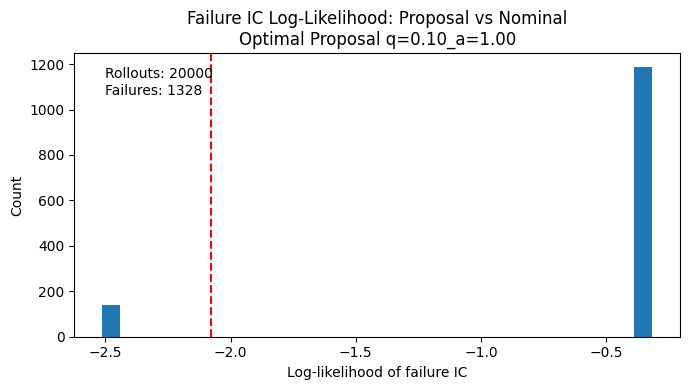

In [74]:
## JSON Plot 4   Failure IC log-likelihood histogram for optimal proposal

opt_data = loaded[OPT_KEY]
fail_props = opt_data["failure_logp_proposals"]
n_fail = opt_data["num_failures"]
n_roll = opt_data["num_rollouts"]

NOMINAL_LOGP = 3 * np.log(0.5)  # constant for all IC failures

fig, ax = plt.subplots(figsize=(7, 4))

if fail_props:
    ax.hist(fail_props, bins=30)

ax.axvline(NOMINAL_LOGP, color="red", linestyle="--", linewidth=1.5)

ax.set_title(f"Failure IC Log-Likelihood: Proposal vs Nominal\nOptimal Proposal {OPT_KEY}")
ax.set_xlabel("Log-likelihood of failure IC")
ax.set_ylabel("Count")

ax.text(0.05, 0.95,
        f"Rollouts: {n_roll}\nFailures: {n_fail}",
        transform=ax.transAxes, verticalalignment='top')

plt.tight_layout()
plt.savefig("media/plot_failure_ic_optimal.png", dpi=150)
plt.show()

## Failure Log-Likelihood Histogram   All data Pooled

C:\Users\meteg\AppData\Local\Temp\ipykernel_33388\1045455968.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


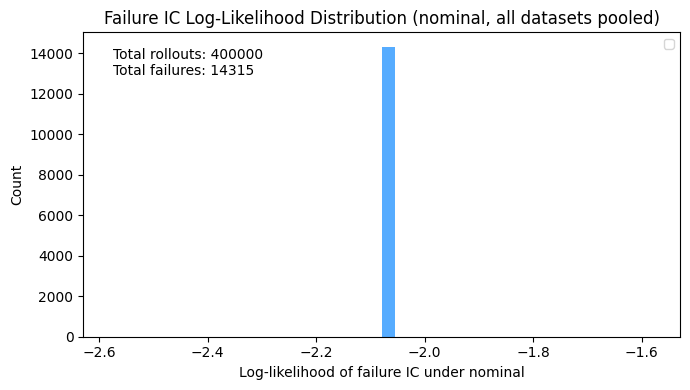

In [75]:
## JSON Plot 4   Failure IC log-likelihood histogram under nominal ICs

all_fail_logps = [lp for dp in sorted(loaded.keys()) for lp in loaded[dp]["failure_logp_nominals"]]

total_r = sum(loaded[dp]["num_rollouts"] for dp in sorted(loaded.keys()))
total_f = sum(loaded[dp]["num_failures"] for dp in sorted(loaded.keys()))

fig, ax = plt.subplots(figsize=(7, 4))

if all_fail_logps:
    ax.hist(all_fail_logps, bins=40, color="dodgerblue", alpha=0.75)

ax.set_title("Failure IC Log-Likelihood Distribution (nominal, all datasets pooled)")
ax.set_xlabel("Log-likelihood of failure IC under nominal")
ax.set_ylabel("Count")

ax.text(0.05, 0.95,
        f"Total rollouts: {total_r}\nTotal failures: {total_f}",
        transform=ax.transAxes, verticalalignment='top')

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("media/plot_failure_ic_nominal_hist.png", dpi=150)
plt.show()

## Proposal Parameter IS p_fail Heatmap (lane_bias_q x beta_alpha)

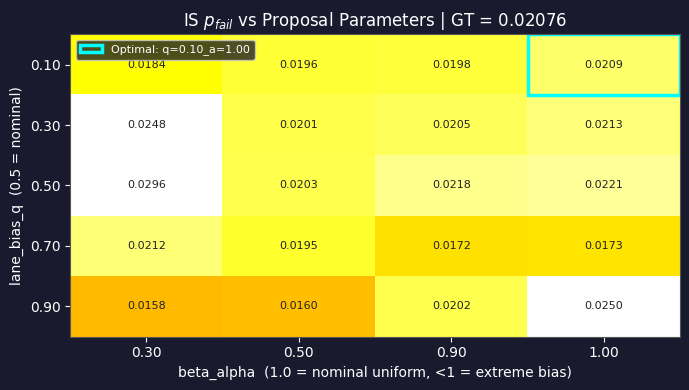

In [76]:
# Extract unique q and alpha values from loaded keys
qs     = sorted({v["lane_bias_q"] for v in loaded.values()})
alphas = sorted({v["beta_alpha"]  for v in loaded.values()})

def _config_key(q, a): return f"q={q:.2f}_a={a:.2f}"

# Build 2D grid of p_fail_is
grid_pfail = np.full((len(qs), len(alphas)), np.nan)
for i, q in enumerate(qs):
    for j, a in enumerate(alphas):
        k = _config_key(q, a)
        if k in loaded:
            grid_pfail[i, j] = loaded[k]["p_fail_is"]

fig, ax = plt.subplots(figsize=(7, 4))
style_ax_dark(ax, fig)

im = ax.imshow(grid_pfail, aspect="auto", cmap="hot",
               vmin=0, vmax=max(float(np.nanmax(grid_pfail))-.005, 0))


# Remove grid
ax.grid(False)

ax.set_xticks(range(len(alphas)))
ax.set_xticklabels([f"{a:.2f}" for a in alphas])
ax.set_yticks(range(len(qs)))
ax.set_yticklabels([f"{q:.2f}" for q in qs])
ax.set_xlabel(r"beta_alpha  (1.0 = nominal uniform, <1 = extreme bias)")
ax.set_ylabel(r"lane_bias_q  (0.5 = nominal)")
ax.set_title(r"IS $p_{fail}$ vs Proposal Parameters | GT = " +
             f"{GROUND_TRUTH_P_FAIL:.5f}")

# Annotate cells
for i in range(len(qs)):
    for j in range(len(alphas)):
        if not np.isnan(grid_pfail[i, j]):
            ax.text(j, i, f"{grid_pfail[i,j]:.4f}", ha="center", va="center",
                    fontsize=8,
                    color="#222" if grid_pfail[i,j] > float(np.nanmax(grid_pfail)) / 2 else "black")

# Highlight optimal
opt_i = qs.index(OPT_Q)
opt_j = alphas.index(OPT_ALPHA)
ax.add_patch(plt.Rectangle((opt_j - 0.5, opt_i - 0.5), 1, 1,
             fill=False, edgecolor="cyan", linewidth=2.5, label=f"Optimal: {OPT_KEY}"))
ax.legend(loc="upper left", fontsize=8, facecolor="#222", labelcolor="white")

plt.tight_layout()
plt.savefig("media/ic_pfail_heatmap.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## IS vs Direct Sampling Convergence

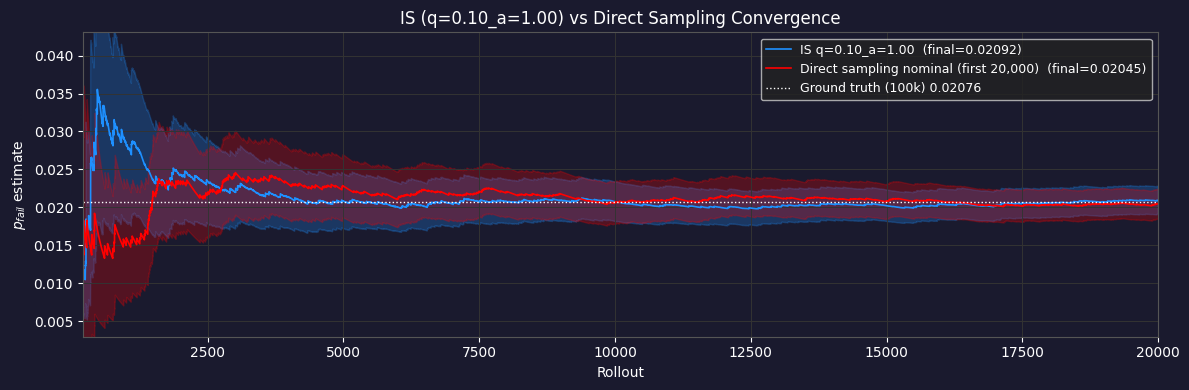

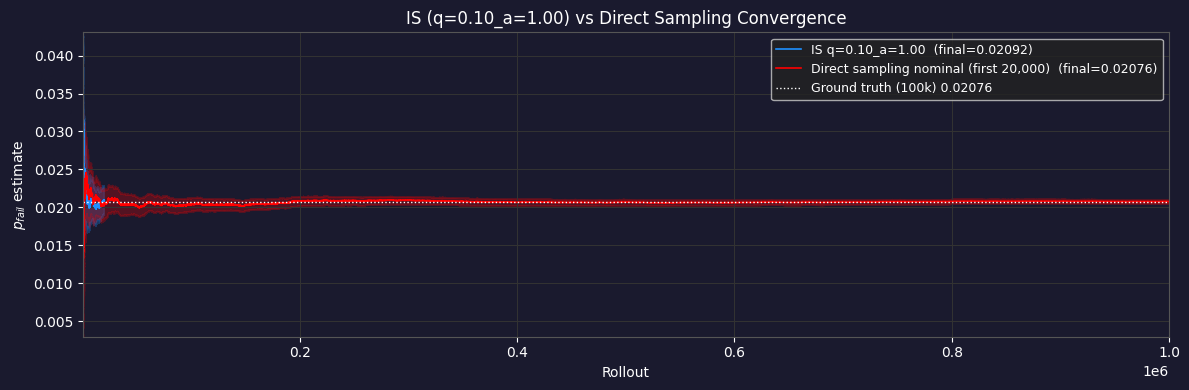

In [77]:
opt_data       = loaded[OPT_KEY]
is_weights_opt = opt_data["is_weights"]

is_mean, is_lo, is_hi = running_stats(is_weights_opt)
is_ep = np.arange(1, len(is_mean) + 1)
N_IS  = len(is_weights_opt)

ds_compare            = DS_WEIGHTS_100K[:N_IS]
ds_mean, ds_lo, ds_hi = running_stats(ds_compare)
ds_ep = np.arange(1, len(ds_mean) + 1)

SKIP_FULL = 200
y_vals = np.concatenate([is_mean[SKIP_FULL:], ds_mean[SKIP_FULL:]])
y_pad  = max((y_vals.max() - y_vals.min()) * 0.3, 0.001)
y_lo_f = max(0.0, y_vals.min() - y_pad)
y_hi_f = y_vals.max() + y_pad

# First figure: zoomed to actual N_IS
fig, ax = plt.subplots(figsize=(12, 4))
style_ax_dark(ax, fig)

ax.fill_between(is_ep, is_lo, is_hi, alpha=0.25, color="dodgerblue")
ax.plot(is_ep, is_mean, color="dodgerblue", lw=1.2,
        label=f"IS {OPT_KEY}  (final={is_mean[-1]:.5f})")
ax.fill_between(ds_ep, ds_lo, ds_hi, alpha=0.25, color="red")
ax.plot(ds_ep, ds_mean, color="red", lw=1.2,
        label=f"Direct sampling nominal (first {N_IS:,})  (final={ds_mean[-1]:.5f})")
ax.axhline(GROUND_TRUTH_P_FAIL, color="white", linestyle=":", linewidth=1.0,
           label=f"Ground truth (100k) {GROUND_TRUTH_P_FAIL:.5f}")

ax.set_ylim(y_lo_f, y_hi_f)
ax.set_xlim(SKIP_FULL, N_IS)
ax.set_xlabel("Rollout")
ax.set_ylabel(r"$p_{fail}$ estimate")
ax.set_title(f"IS ({OPT_KEY}) vs Direct Sampling Convergence", fontsize=12)
ax.legend(facecolor="#222", labelcolor="white", fontsize=9)
plt.tight_layout()
plt.savefig("media/ic_convergence_zoom.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# Second figure: full x-axis up to 100_000
ds_mean, ds_lo, ds_hi = running_stats(DS_WEIGHTS_100K)
ds_ep = np.arange(1, len(ds_mean) + 1)

fig, ax = plt.subplots(figsize=(12, 4))
style_ax_dark(ax, fig)

ax.fill_between(is_ep, is_lo, is_hi, alpha=0.25, color="dodgerblue")
ax.plot(is_ep, is_mean, color="dodgerblue", lw=1.2,
        label=f"IS {OPT_KEY}  (final={is_mean[-1]:.5f})")
ax.fill_between(ds_ep, ds_lo, ds_hi, alpha=0.25, color="red")
ax.plot(ds_ep, ds_mean, color="red", lw=1.2,
        label=f"Direct sampling nominal (first {N_IS:,})  (final={ds_mean[-1]:.5f})")
ax.axhline(GROUND_TRUTH_P_FAIL, color="white", linestyle=":", linewidth=1.0,
           label=f"Ground truth (100k) {GROUND_TRUTH_P_FAIL:.5f}")

ax.set_ylim(y_lo_f, y_hi_f)
ax.set_xlim(SKIP_FULL, 1_000_000)
ax.set_xlabel("Rollout")
ax.set_ylabel(r"$p_{fail}$ estimate")
ax.set_title(f"IS ({OPT_KEY}) vs Direct Sampling Convergence", fontsize=12)
ax.legend(facecolor="#222", labelcolor="white", fontsize=9)
plt.tight_layout()
plt.savefig("media/ic_convergence_full.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()


## Convergence (zoomed y-axis)

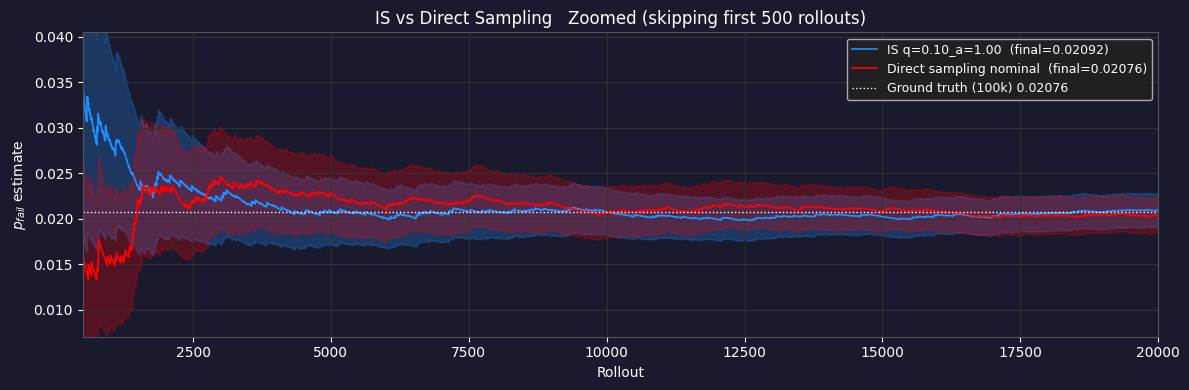

In [78]:
SKIP = 500  # skip early 

y_vals = np.concatenate([is_mean[SKIP:], ds_mean[SKIP:]])
y_pad  = max((y_vals.max() - y_vals.min()) * 0.3, 0.002)
y_lo_z = max(0.0, y_vals.min() - y_pad)
y_hi_z = y_vals.max() + y_pad

fig, ax = plt.subplots(figsize=(12, 4))
style_ax_dark(ax, fig)

ax.fill_between(is_ep[SKIP:], is_lo[SKIP:], is_hi[SKIP:], alpha=0.25, color="dodgerblue")
ax.plot(is_ep[SKIP:], is_mean[SKIP:], color="dodgerblue", lw=1.2,
        label=f"IS {OPT_KEY}  (final={is_mean[-1]:.5f})")

ax.fill_between(ds_ep[SKIP:], ds_lo[SKIP:], ds_hi[SKIP:], alpha=0.25, color="red")
ax.plot(ds_ep[SKIP:], ds_mean[SKIP:], color="red", lw=1.2,
        label=f"Direct sampling nominal  (final={ds_mean[-1]:.5f})")

ax.axhline(GROUND_TRUTH_P_FAIL, color="white", linestyle=":", linewidth=1.0,
           label=f"Ground truth (100k) {GROUND_TRUTH_P_FAIL:.5f}")

ax.set_ylim(y_lo_z, y_hi_z)
ax.set_xlim(SKIP, N_IS)
ax.set_xlabel("Rollout")
ax.set_ylabel(r"$p_{fail}$ estimate")
ax.set_title(f"IS vs Direct Sampling   Zoomed (skipping first {SKIP:,} rollouts)", fontsize=12)
ax.legend(facecolor="#222", labelcolor="white", fontsize=9)
plt.tight_layout()
plt.savefig("media/ic_convergence_stretched.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## Failure Distribution Table (merger vs highway per proposal)

In [79]:
print(f"{'config':>18} | {'n_fail':>7} | {'n_rollout':>9} | {'merger':>8} | "
      f"{'highway':>8} | {'frac_merger':>12} | {'p_fail_IS':>10}")
print("-" * 84)

for k in sorted(loaded.keys()):
    r      = loaded[k]
    ftypes = r.get("failure_types", [])
    nf     = r["num_failures"]
    nm     = ftypes.count("merger")
    nh     = ftypes.count("highway")
    fm     = nm / nf if nf > 0 else float("nan")
    star   = " <-- OPT" if k == OPT_KEY else ""
    print(f"{k:>18} | {nf:>7d} | {r['num_rollouts']:>9,} | "
          f"{nm:>8d} | {nh:>8d} | {fm:>12.3f} | {r['p_fail_is']:>10.5f}{star}")

            config |  n_fail | n_rollout |   merger |  highway |  frac_merger |  p_fail_IS
------------------------------------------------------------------------------------
     q=0.10_a=0.30 |    2289 |    20,000 |        0 |     2289 |        0.000 |    0.01839
     q=0.10_a=0.50 |    1882 |    20,000 |        0 |     1882 |        0.000 |    0.01962
     q=0.10_a=0.90 |    1395 |    20,000 |        0 |     1395 |        0.000 |    0.01980
     q=0.10_a=1.00 |    1328 |    20,000 |        0 |     1328 |        0.000 |    0.02092 <-- OPT
     q=0.30_a=0.30 |    1426 |    20,000 |        0 |     1426 |        0.000 |    0.02481
     q=0.30_a=0.50 |    1148 |    20,000 |        0 |     1148 |        0.000 |    0.02011
     q=0.30_a=0.90 |     847 |    20,000 |        0 |      847 |        0.000 |    0.02050
     q=0.30_a=1.00 |     795 |    20,000 |        0 |      795 |        0.000 |    0.02131
     q=0.50_a=0.30 |     763 |    20,000 |        0 |      763 |        0.000 |    0.029

## IS p_fail Convergence Over Rollouts

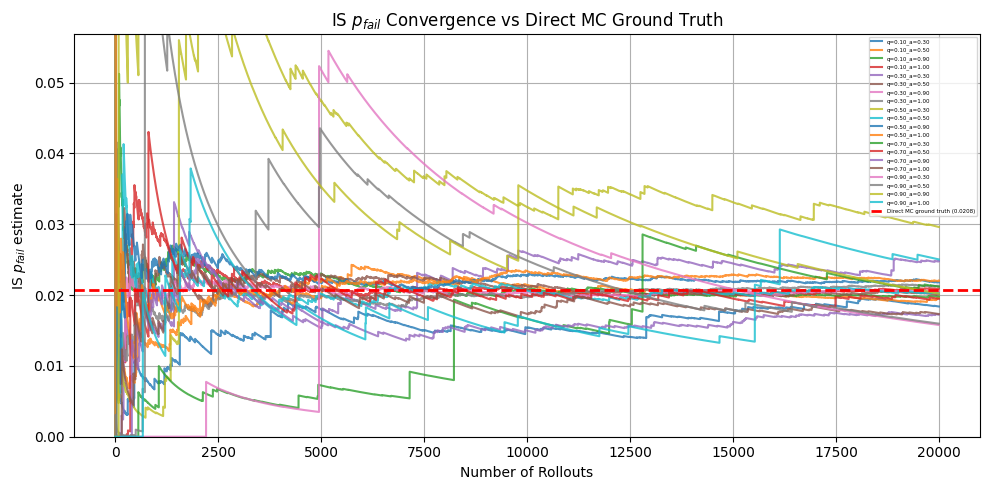

In [80]:
## IS p_fail Convergence Over Rollouts (all configs)

fig, ax = plt.subplots(figsize=(10, 5))

for k in sorted(loaded.keys()):
    weights = np.array(loaded[k]["is_weights"])
    if len(weights) == 0:
        continue
    running_pfail = np.cumsum(weights) / np.arange(1, len(weights) + 1)
    ax.plot(running_pfail, alpha=0.8, label=f"{k}{star}")

ax.axhline(GROUND_TRUTH_P_FAIL, color='red', linestyle='--', linewidth=2,
           label=f"Direct MC ground truth ({GROUND_TRUTH_P_FAIL:.4f})")
ax.set_ylim(0, max(0.05, np.nanmax(running_pfail) * 1.5))
ax.set_xlabel("Number of Rollouts")
ax.set_ylabel("IS $p_{fail}$ estimate")
ax.set_title("IS $p_{fail}$ Convergence vs Direct MC Ground Truth")
ax.legend(fontsize=4)
ax.grid(True)
plt.tight_layout()
plt.savefig("media/plot_is_convergence_all.png", dpi=150)
plt.show()

## Most Likely Failure   Video

Re-runs the env with the optimal proposal until a failure is found, then saves `ic_mlf.mp4`.

In [81]:
import gymnasium as gym
import highway_env
from stable_baselines3 import PPO
from highway_env.envs.merge_env import MergeEnv
from highway_env import utils as henv_utils
import imageio

gym.register_envs(highway_env)
model_vid = PPO.load(MODEL_PATH, device="cpu")


class ICFuzzMergeEnv(MergeEnv):
    """Same as ic_fuzzing_local.py   Beta(alpha,alpha) IS proposal on all IC vars."""
    _BASE_POSITIONS = [90.0, 70.0, 5.0]
    _BASE_SPEEDS    = [29.0, 31.0, 31.5]

    def __init__(self, lane_bias_q: float = 0.5, beta_alpha: float = 1.0, **kwargs):
        self._lane_bias_q = lane_bias_q
        self._beta_alpha  = beta_alpha
        super().__init__(**kwargs)

    def _make_vehicles(self):
        road = self.road
        ego  = self.action_type.vehicle_class(
            road, road.network.get_lane(("a", "b", 1)).position(30.0, 0.0), speed=30.0
        )
        road.vehicles.append(ego)
        other_type = henv_utils.class_from_path(self.config["other_vehicles_type"])
        for base_pos, base_spd in zip(self._BASE_POSITIONS, self._BASE_SPEEDS):
            lane_idx   = 1 if self.np_random.random() < self._lane_bias_q else 0
            u_pos      = float(self.np_random.beta(self._beta_alpha, self._beta_alpha))
            u_spd      = float(self.np_random.beta(self._beta_alpha, self._beta_alpha))
            pos_offset = u_pos * 10.0 - 5.0
            spd_offset = u_spd * 2.0 - 1.0
            lane       = road.network.get_lane(("a", "b", lane_idx))
            position   = lane.position(base_pos + pos_offset, 0.0)
            road.vehicles.append(other_type(road, position, speed=base_spd + spd_offset))
        merging_v = other_type(
            road, road.network.get_lane(("j", "k", 0)).position(110.0, 0.0), speed=20.0
        )
        merging_v.target_speed = 30.0
        road.vehicles.append(merging_v)
        self.vehicle = ego


env_vid = ICFuzzMergeEnv(lane_bias_q=OPT_Q, beta_alpha=OPT_ALPHA, render_mode="rgb_array")
mlf_frames = None
TRIES = 200
print(f"Searching for a failure with {OPT_KEY} (up to {TRIES} attempts)...")

for attempt in range(TRIES):
    obs, _ = env_vid.reset()
    done = truncated = False
    frames = []
    while not (done or truncated):
        frames.append(env_vid.render())
        action, _ = model_vid.predict(obs, deterministic=True)
        obs, _, done, truncated, _ = env_vid.step(action)
    if getattr(env_vid.unwrapped.vehicle, "crashed", False):
        mlf_frames = frames
        print(f"  Failure found on attempt {attempt + 1}!")
        break

env_vid.close()

if mlf_frames is not None:
    imageio.mimsave("media/ic_mlf.mp4", mlf_frames, fps=30)
    print("Saved: media/ic_mlf.mp4")
else:
    print(f"No failure found in {TRIES} attempts.")

Searching for a failure with q=0.10_a=1.00 (up to 200 attempts)...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Failure found on attempt 1!
Saved: media/ic_mlf.mp4


## Summary

In [82]:
print("=" * 65)
print("IC Fuzzing (Beta IS over all IC vars)   Summary")
print("=" * 65)
print(f"  Ground truth p_fail (100k DS) : {GROUND_TRUTH_P_FAIL:.5f}")
print(f"  Optimal proposal              : {OPT_KEY}")
print(f"    lane_bias_q = {OPT_Q}  (nominal=0.5)")
print(f"    beta_alpha  = {OPT_ALPHA}  (nominal=1.0, <1 biases pos/spd to extremes)")
print(f"  IS p_fail (optimal)           : {loaded[OPT_KEY]['p_fail_is']:.5f}")
print(f"  Failures found (optimal)      : {loaded[OPT_KEY]['num_failures']} "
      f"/ {loaded[OPT_KEY]['num_rollouts']:,}")
print()
print("All configs   relative error vs ground truth:")
for k in sorted(loaded.keys()):
    pf  = loaded[k]["p_fail_is"]
    err = (pf - GROUND_TRUTH_P_FAIL) / GROUND_TRUTH_P_FAIL * 100
    star = " <- OPT" if k == OPT_KEY else ""
    print(f"  {k}  IS={pf:.5f}  err={err:+.1f}%{star}")

IC Fuzzing (Beta IS over all IC vars)   Summary
  Ground truth p_fail (100k DS) : 0.02076
  Optimal proposal              : q=0.10_a=1.00
    lane_bias_q = 0.1  (nominal=0.5)
    beta_alpha  = 1.0  (nominal=1.0, <1 biases pos/spd to extremes)
  IS p_fail (optimal)           : 0.02092
  Failures found (optimal)      : 1328 / 20,000

All configs   relative error vs ground truth:
  q=0.10_a=0.30  IS=0.01839  err=-11.4%
  q=0.10_a=0.50  IS=0.01962  err=-5.5%
  q=0.10_a=0.90  IS=0.01980  err=-4.6%
  q=0.10_a=1.00  IS=0.02092  err=+0.8% <- OPT
  q=0.30_a=0.30  IS=0.02481  err=+19.5%
  q=0.30_a=0.50  IS=0.02011  err=-3.1%
  q=0.30_a=0.90  IS=0.02050  err=-1.3%
  q=0.30_a=1.00  IS=0.02131  err=+2.6%
  q=0.50_a=0.30  IS=0.02962  err=+42.7%
  q=0.50_a=0.50  IS=0.02026  err=-2.4%
  q=0.50_a=0.90  IS=0.02179  err=+5.0%
  q=0.50_a=1.00  IS=0.02205  err=+6.2%
  q=0.70_a=0.30  IS=0.02119  err=+2.1%
  q=0.70_a=0.50  IS=0.01946  err=-6.3%
  q=0.70_a=0.90  IS=0.01723  err=-17.0%
  q=0.70_a=1.00  IS=0.01